# L2 Vowel Transfer Modeling Pipeline

**Goal:** Predict L2 English vowel displacements from L1 vowel-system features.

Pipeline:
1. Scan corpus & build metadata (ALLSSTAR: 10 L1s + native ENG controls)
2. Expanded acoustic feature extraction (F1, F2, F3, F0, duration, spectral COG/skewness)
3. Extract native English baseline, L2 English, and L1 vowels for all speakers
4. Build per-speaker vowel-system summaries (centroids + dispersions)
5. Unsupervised exploration (GMM clustering, PCA/UMAP)
6. Construct paired dataset: X = L1 system features, Y = L2 displacement from native
7. Train models: Ridge → GPR → Gradient Boosting → MLP
8. Evaluate: Leave-one-language-out & leave-one-speaker-out CV

In [10]:
# ── Cell 1: Imports, constants, and corpus metadata scan ──

import os
import re
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import soundfile as sf
import parselmouth
from parselmouth.praat import call
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

from scipy.spatial.distance import mahalanobis as _mahal
from scipy.spatial import ConvexHull

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error

matplotlib.rcParams.update({"figure.dpi": 100})
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths ──
DATA_ROOT = Path("../Data/ALLSSTAR")
CACHE_DIR = Path("../Data/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CEILING_CACHE_PATH = os.path.join(r"C:\Users\Yuheng\l2Vowel_ML\Data", "speaker_ceilings.json")

# ── Scan corpus folders and build file_metadata ──
records = []
pattern = re.compile(r"^ALL_(\d+)_([MF])_([A-Z]{3})_([A-Z]{3})_([A-Z0-9]{2,3})$")

for folder in sorted(DATA_ROOT.iterdir()):
    if not folder.is_dir():
        continue
    wav_lookup = {f.stem: f.resolve() for f in folder.glob("*.wav")}
    tg_lookup = {f.stem: f.resolve() for f in folder.glob("*.TextGrid")}
    all_stems = set(wav_lookup) | set(tg_lookup)

    for stem in sorted(all_stems):
        m = pattern.match(stem)
        if not m:
            continue
        participant_id, gender, native_lang, task_lang, task = m.groups()
        records.append({
            "filename_stem": stem,
            "folder": folder.name,
            "participant_id": int(participant_id),
            "gender": gender,
            "native_language": native_lang,
            "task_language": task_lang,
            "task": task,
            "wav_path": str(wav_lookup[stem]) if stem in wav_lookup else None,
            "textgrid_path": str(tg_lookup[stem]) if stem in tg_lookup else None,
        })

file_metadata = pd.DataFrame(records)
file_metadata["has_wav"] = file_metadata["wav_path"].notna()
file_metadata["has_textgrid"] = file_metadata["textgrid_path"].notna()

# Summary
n_l2 = file_metadata[file_metadata["native_language"] != "ENG"]["participant_id"].nunique()
n_native = file_metadata[file_metadata["native_language"] == "ENG"]["participant_id"].nunique()
print(f"Total files: {len(file_metadata)} | Folders: {file_metadata['folder'].nunique()}")
print(f"Native ENG speakers: {n_native} | L2 speakers: {n_l2}")
print(f"L1 backgrounds: {sorted(file_metadata['native_language'].unique())}")
print(f"WAV coverage: {file_metadata['has_wav'].sum()}/{len(file_metadata)} | "
      f"TextGrid coverage: {file_metadata['has_textgrid'].sum()}/{len(file_metadata)}")
print(f"\nFiles per native language:\n{file_metadata['native_language'].value_counts().sort_index().to_string()}")

Total files: 755 | Folders: 97
Native ENG speakers: 26 | L2 speakers: 65
L1 backgrounds: ['CMN', 'ENG', 'FRA', 'GER', 'GRE', 'JPN', 'KOR', 'RUS', 'SPA', 'TUR', 'VIE']
WAV coverage: 755/755 | TextGrid coverage: 728/755

Files per native language:
native_language
CMN    140
ENG    129
FRA     10
GER     16
GRE      8
JPN     30
KOR    110
RUS     40
SPA    110
TUR    130
VIE     32


## Step 1: Core Utility Functions

TextGrid parser, vowel inventories for all 10 L1 phone systems, and normalization helpers.
Reused from `L2_vowel_formant_analysis.ipynb`.

In [11]:
# ── Cell 2: TextGrid parser + vowel inventories + helpers ──

def parse_textgrid(path):
    """Parse a Praat long-format TextGrid into a list of tier dicts."""
    for enc in ("utf-8", "utf-16", "utf-16-le", "latin-1"):
        try:
            with open(path, "r", encoding=enc) as f:
                raw = f.read()
            break
        except (UnicodeDecodeError, UnicodeError):
            continue

    tiers = []
    tier_blocks = re.split(r'item\s*\[\d+\]\s*:', raw)
    for block in tier_blocks[1:]:
        tier = {}
        tier["class"] = re.search(r'class\s*=\s*"([^"]+)"', block).group(1)
        tier["name"] = re.search(r'name\s*=\s*"([^"]*)"', block).group(1)
        tier["xmin"] = float(re.search(r'(?<!\[)xmin\s*=\s*(-?[\d.]+)', block).group(1))
        tier["xmax"] = float(re.search(r'(?<!\[)xmax\s*=\s*(-?[\d.]+)', block).group(1))
        intervals = []
        for m in re.finditer(
            r'intervals\s*\[\d+\]\s*:\s*'
            r'xmin\s*=\s*(-?[\d.]+)\s*'
            r'xmax\s*=\s*(-?[\d.]+)\s*'
            r'text\s*=\s*"([^"]*)"',
            block,
        ):
            intervals.append({
                "xmin": float(m.group(1)),
                "xmax": float(m.group(2)),
                "text": m.group(3).strip(),
            })
        tier["intervals"] = intervals
        tiers.append(tier)
    return tiers

# ── Vowel inventories for all phone systems ──

ARPABET_VOWELS = {
    "AA", "AE", "AH", "AO", "AW", "AX", "AY",
    "EH", "ER", "EY", "IH", "IY", "IX",
    "OW", "OY", "UH", "UW", "UX",
}

CMN_VOWEL_BASES = {
    "a", "e", "i", "o", "u", "v", "ii",
    "ai", "ao", "ei", "ou",
    "ia", "iao", "ie", "iu", "iou",
    "ua", "uai", "ue", "uei", "uo", "va",
}

FRA_VOWELS = {
    "a", "e", "i", "o", "u", "y",
    "AE", "E", "EU", "O", "OE", "AX",
    "A~", "E~", "OE~", "o~",
}

GER_VOWELS = {
    "a", "e", "i", "o", "u", "ae", "oe", "ue",
    "al", "el", "il", "ol", "ul", "ael", "oel", "uel",
    "atu", "etu", "aI", "aU",
}

KOR_VOWELS = {
    "A", "AE", "E", "EO", "EU", "I", "O", "OE", "U", "UE",
    "iE", "iEO", "iO", "iU", "euI", "oA", "uEO",
}

RUS_VOWELS = {"a", "i", "i2", "o", "u", "jA", "jE", "jU"}

SPA_VOWELS = {"a", "e", "i", "o", "u", "a+", "i+", "o+", "u+", "eU"}

TUR_VOWELS = {"ab", "e", "i", "i2", "o", "oe", "u", "ue"}

VIE_VOWEL_BASES = {
    "a1", "a2", "a3", "e1", "e2", "i",
    "o1", "o2", "o3", "u1", "u2",
    "ai", "ao", "au", "ay", "ay3",
    "eo", "eu", "ie2", "ieu",
    "oa", "oi", "oi2", "oi3",
    "ua", "ua2", "uu2", "uy", "uoi3",
}


def _detect_phone_system(task_language: str) -> str:
    return "ARPABET" if task_language == "ENG" else task_language


def is_vowel(phone_label: str, task_language: str = "ENG") -> bool:
    system = _detect_phone_system(task_language)

    if system == "ARPABET":
        return phone_label.rstrip("0123456789") in ARPABET_VOWELS
    if system == "CMN":
        return phone_label.rstrip("12345") in CMN_VOWEL_BASES
    if system == "FRA":
        return phone_label in FRA_VOWELS
    if system == "GER":
        return phone_label in GER_VOWELS
    if system == "KOR":
        return phone_label in KOR_VOWELS
    if system == "RUS":
        return phone_label in RUS_VOWELS
    if system == "SPA":
        return phone_label in SPA_VOWELS
    if system == "TUR":
        return phone_label in TUR_VOWELS
    if system == "VIE":
        base = re.sub(r"_T\d$", "", phone_label)
        return base in VIE_VOWEL_BASES
    # Fallback for JPN, GRE, etc.
    return phone_label.rstrip("0123456789") in ARPABET_VOWELS


def normalize_vowel_label(phone_label: str, task_language: str = "ENG") -> str:
    system = _detect_phone_system(task_language)
    if system == "ARPABET":
        base = phone_label.rstrip("0123456789")
        if base == "AH" and len(phone_label) > len(base):
            return phone_label  # keep AH0/AH1/AH2 distinct
        return base
    if system == "CMN":
        return phone_label.rstrip("12345")
    if system == "VIE":
        return re.sub(r"_T\d$", "", phone_label)
    return phone_label


ARPABET_TO_IPA = {
    "IY": "i", "IH": "\u026a", "EH": "\u025b", "AE": "\u00e6",
    "AA": "\u0251", "AO": "\u0254", "UH": "\u028a", "UW": "u",
    "AH1": "\u028c", "AH2": "\u028c", "AH0": "\u0259",
    "ER": "\u025d", "AX": "\u0259", "IX": "\u026a", "UX": "\u028a",
    "AW": "a\u028a", "AY": "a\u026a", "EY": "e\u026a",
    "OW": "o\u028a", "OY": "\u0254\u026a",
}

IPA_MONOPHTHONGS = {"i", "\u026a", "\u025b", "\u00e6", "\u0251", "\u028a", "u", "\u028c"}

# 8 ARPAbet labels that map to the target monophthongs
TARGET_ENG_VOWELS = {"IY", "IH", "EH", "AE", "AA", "UH", "UW", "AH1", "AH2"}

def add_ipa_column(df):
    """Map ARPAbet vowel labels to IPA, keep only 8 monophthongs."""
    df_ipa = df.copy()
    df_ipa["ipa_symbol"] = df_ipa["vowel"].map(ARPABET_TO_IPA)
    df_ipa = df_ipa.dropna(subset=["ipa_symbol"])
    df_ipa = df_ipa[df_ipa["ipa_symbol"].isin(IPA_MONOPHTHONGS)]
    return df_ipa if not df_ipa.empty else None


def lobanov_normalize(df, features=None):
    """Lobanov (z-score) normalization per speaker for arbitrary feature columns."""
    if features is None:
        features = ["F1", "F2"]
    stats = df.groupby("participant_id")[features].agg(["mean", "std"])
    for feat in features:
        col_mean = stats[(feat, "mean")]
        col_std = stats[(feat, "std")]
        df[f"{feat}_norm"] = df.apply(
            lambda r: (r[feat] - col_mean[r["participant_id"]])
                      / col_std[r["participant_id"]]
            if col_std.get(r["participant_id"], 0) > 0 else 0.0,
            axis=1,
        )
    return df

print("Core utilities loaded.")

Core utilities loaded.


## Step 2: Expanded Feature Extraction

Extends the original F1/F2 pipeline to also extract **F3**, **F0**, **spectral center of gravity**, and **spectral skewness** per vowel token. Uses per-speaker optimized formant ceilings from `speaker_ceilings.json`.

In [12]:
# ── Cell 3: Expanded feature extraction (F1-F3, F0, spectral moments) ──

ACOUSTIC_FEATURES = ["F1", "F2", "F3", "F0", "duration_ms", "spectral_cog", "spectral_skewness"]

def extract_formants_expanded(audio_segment, sr, max_formant=5500, n_formants=5,
                              n_samples=5):
    """Extract F1, F2, F3, F0, spectral COG, and spectral skewness from the
    middle third of a vowel segment."""
    snd = parselmouth.Sound(audio_segment, sampling_frequency=sr)

    # Formants (F1-F3) from middle third
    formant_obj = call(snd, "To Formant (burg)", 0.0, n_formants, max_formant, 0.025, 50.0)
    t_start = snd.duration / 3.0
    t_end = snd.duration * 2.0 / 3.0
    times = np.linspace(t_start, t_end, n_samples)

    f_vals = {1: [], 2: [], 3: []}
    for t in times:
        for fi in (1, 2, 3):
            v = call(formant_obj, "Get value at time", fi, t, "Hertz", "Linear")
            if not np.isnan(v) and v > 0:
                f_vals[fi].append(v)

    f1 = np.mean(f_vals[1]) if f_vals[1] else float("nan")
    f2 = np.mean(f_vals[2]) if f_vals[2] else float("nan")
    f3 = np.mean(f_vals[3]) if f_vals[3] else float("nan")

    # F0 (pitch) at midpoint
    pitch_obj = call(snd, "To Pitch", 0.0, 75.0, 600.0)
    t_mid = snd.duration / 2.0
    f0 = call(pitch_obj, "Get value at time", t_mid, "Hertz", "Linear")
    if np.isnan(f0) or f0 <= 0:
        f0 = float("nan")

    # Spectral moments from the middle third
    try:
        s_mid = int(len(audio_segment) / 3)
        e_mid = int(len(audio_segment) * 2 / 3)
        snd_mid = parselmouth.Sound(audio_segment[s_mid:e_mid], sampling_frequency=sr)
        spectrum = call(snd_mid, "To Spectrum", "yes")
        spectral_cog = call(spectrum, "Get centre of gravity...", 2.0)
        spectral_skew = call(spectrum, "Get skewness...", 2.0)
    except Exception:
        spectral_cog = float("nan")
        spectral_skew = float("nan")

    return f1, f2, f3, f0, spectral_cog, spectral_skew


def load_ceiling_cache():
    """Load the speaker ceiling cache from disk."""
    if os.path.exists(CEILING_CACHE_PATH):
        with open(CEILING_CACHE_PATH, "r") as f:
            return json.load(f)
    return {}

_ceiling_cache = load_ceiling_cache()

def get_speaker_ceiling(participant_id, gender):
    """Look up optimized ceiling for a speaker, fall back to gender default."""
    key = str(participant_id)
    entry = _ceiling_cache.get(key, {})
    ceilings = entry.get("ceilings", {})
    # Find any ENG context key
    for ctx_key, ctx_val in ceilings.items():
        if ctx_key.startswith("ENG:"):
            return ctx_val["ceiling"]
    return 5500 if gender == "F" else 5000


def extract_vowel_formants_from_file(meta_row, max_formant_override=None):
    """Extract expanded acoustic features for all vowel tokens in one file."""
    stem = meta_row["filename_stem"]
    tg_p = meta_row["textgrid_path"]
    wav_p = meta_row["wav_path"]
    if tg_p is None or wav_p is None:
        return []
    if not os.path.exists(str(wav_p)):
        return []

    tg = parse_textgrid(tg_p)
    phone_tier = None
    for t in tg:
        if "phone" in t["name"].lower():
            phone_tier = t
            break
    if phone_tier is None:
        phone_tier = tg[-1]

    aud, sr_file = sf.read(wav_p)
    if aud.ndim > 1:
        aud = aud[:, 0]

    max_f = max_formant_override or get_speaker_ceiling(
        meta_row["participant_id"], meta_row["gender"])
    tl = meta_row["task_language"]
    results = []

    for iv in phone_tier["intervals"]:
        lbl = iv["text"].strip()
        if not lbl or lbl in ("sil", "sp", "SIL", "SP"):
            continue
        if not is_vowel(lbl, tl):
            continue
        dur = iv["xmax"] - iv["xmin"]
        if dur < 0.05:
            continue

        s0 = int(iv["xmin"] * sr_file)
        s1 = int(iv["xmax"] * sr_file)
        seg = aud[s0:s1]
        if len(seg) < 100:
            continue

        try:
            f1, f2, f3, f0, cog, skew = extract_formants_expanded(
                seg, sr_file, max_formant=max_f)
        except Exception:
            continue

        if np.isnan(f1) or np.isnan(f2) or f1 <= 0 or f2 <= 0:
            continue

        results.append({
            "stem": stem,
            "participant_id": meta_row["participant_id"],
            "gender": meta_row["gender"],
            "native_language": meta_row["native_language"],
            "task_language": tl,
            "task": meta_row["task"],
            "vowel": normalize_vowel_label(lbl, tl),
            "vowel_raw": lbl,
            "F1": f1,
            "F2": f2,
            "F3": f3,
            "F0": f0,
            "duration_ms": dur * 1000,
            "spectral_cog": cog,
            "spectral_skewness": skew,
            "xmin": iv["xmin"],
            "xmax": iv["xmax"],
            "wav_path": wav_p,
            "textgrid_path": tg_p,
        })
    return results


def process_file_subset(metadata_subset, label=""):
    """Process all files in a metadata subset, return token-level DataFrame."""
    all_tokens = []
    n_files = len(metadata_subset)
    for i, (_, mrow) in enumerate(metadata_subset.iterrows()):
        if (i + 1) % 20 == 0 or i == 0:
            print(f"  {label} [{i+1}/{n_files}] {mrow['filename_stem']}")
        tokens = extract_vowel_formants_from_file(mrow)
        all_tokens.extend(tokens)
    df = pd.DataFrame(all_tokens)
    if not df.empty:
        print(f"  {label} Done: {len(df)} vowel tokens from {n_files} files")
    else:
        print(f"  {label} WARNING: 0 tokens extracted from {n_files} files")
    return df

print("Expanded extraction functions ready.")

Expanded extraction functions ready.


## Step 3: Extract All Three Vowel Pools

- **Native ENG** (ENG-ENG): 26 native speakers → ground-truth vowel targets
- **L2 ENG**: L2 speakers reading English tasks → what we want to predict
- **L1**: L2 speakers reading L1 tasks → input features for the model

In [13]:
# ── Cell 4: Extract native ENG-ENG baseline (with disk cache) ──

NATIVE_CACHE = CACHE_DIR / "df_native.csv"

if NATIVE_CACHE.exists():
    df_native = pd.read_csv(NATIVE_CACHE)
    print(f"Loaded native ENG from cache: {len(df_native)} tokens")
else:
    native_meta = file_metadata[
        (file_metadata["native_language"] == "ENG") &
        (file_metadata["has_wav"]) &
        (file_metadata["has_textgrid"])
    ].copy()

    print(f"Native ENG files to process: {len(native_meta)} "
          f"({native_meta['participant_id'].nunique()} speakers)")

    df_native = process_file_subset(native_meta, label="Native ENG")

    # Filter to target monophthongs only
    df_native = df_native[df_native["vowel"].isin(TARGET_ENG_VOWELS)].copy()
    df_native["ipa_symbol"] = df_native["vowel"].map(ARPABET_TO_IPA)
    df_native.to_csv(NATIVE_CACHE, index=False)
    print(f"Saved native ENG cache → {NATIVE_CACHE}")

print(f"\nNative ENG monophthong tokens: {len(df_native)}")
print(df_native.groupby("vowel")[["F1", "F2", "F3"]].agg(["mean", "count"]).round(0))

Native ENG files to process: 129 (26 speakers)
  Native ENG [1/129] ALL_049_F_ENG_ENG_DHR
  Native ENG [20/129] ALL_069_F_ENG_ENG_DHR
  Native ENG [40/129] ALL_064_F_ENG_ENG_HT1
  Native ENG [60/129] ALL_058_F_ENG_ENG_HT2
  Native ENG [80/129] ALL_051_F_ENG_ENG_LPP
  Native ENG [100/129] ALL_072_F_ENG_ENG_LPP
  Native ENG [120/129] ALL_066_M_ENG_ENG_NWS
  Native ENG Done: 32621 vowel tokens from 129 files
Saved native ENG cache → ..\Data\cache\df_native.csv

Native ENG monophthong tokens: 16990
          F1            F2            F3      
        mean count    mean count    mean count
vowel                                         
AA     789.0  1545  1317.0  1545  2534.0  1545
AE     748.0  2734  1795.0  2734  2696.0  2734
AH1    683.0  1705  1444.0  1705  2701.0  1705
AH2    700.0   137  1495.0   137  2717.0   137
EH     671.0  2644  1732.0  2644  2594.0  2644
IH     489.0  2327  1981.0  2327  2742.0  2327
IY     398.0  4420  2298.0  4420  2837.0  4420
UH     512.0   439  1487.0   4

In [14]:
# ── Cell 5: Extract L2 English vowels for all L2 speakers (with disk cache) ──

L2_CACHE = CACHE_DIR / "df_l2.csv"

if L2_CACHE.exists():
    df_l2 = pd.read_csv(L2_CACHE)
    print(f"Loaded L2 ENG from cache: {len(df_l2)} tokens")
else:
    l2_eng_meta = file_metadata[
        (file_metadata["native_language"] != "ENG") &
        (file_metadata["task_language"] == "ENG") &
        (file_metadata["has_wav"]) &
        (file_metadata["has_textgrid"])
    ].copy()

    print(f"L2 ENG files to process: {len(l2_eng_meta)} "
          f"({l2_eng_meta['participant_id'].nunique()} speakers, "
          f"{sorted(l2_eng_meta['native_language'].unique())})")

    df_l2 = process_file_subset(l2_eng_meta, label="L2 ENG")

    # Filter to target monophthongs
    df_l2 = df_l2[df_l2["vowel"].isin(TARGET_ENG_VOWELS)].copy()
    df_l2["ipa_symbol"] = df_l2["vowel"].map(ARPABET_TO_IPA)
    df_l2.to_csv(L2_CACHE, index=False)
    print(f"Saved L2 ENG cache → {L2_CACHE}")

print(f"\nL2 ENG monophthong tokens: {len(df_l2)}")
print(f"Speakers with data: {df_l2['participant_id'].nunique()}")
print(df_l2.groupby("native_language")["participant_id"].nunique())

L2 ENG files to process: 325 (65 speakers, ['CMN', 'FRA', 'GER', 'GRE', 'JPN', 'KOR', 'RUS', 'SPA', 'TUR', 'VIE'])
  L2 ENG [1/325] ALL_005_M_CMN_ENG_DHR
  L2 ENG [20/325] ALL_020_M_CMN_ENG_HT1
  L2 ENG [40/325] ALL_037_M_CMN_ENG_HT2
  L2 ENG [60/325] ALL_016_M_CMN_ENG_NWS
  L2 ENG [80/325] ALL_001_F_GER_ENG_HT2
  L2 ENG [100/325] ALL_013_M_JPN_ENG_LPP
  L2 ENG [120/325] ALL_094_F_KOR_ENG_HT1
  L2 ENG [140/325] ALL_023_M_KOR_ENG_LPP
  L2 ENG [160/325] ALL_121_F_KOR_ENG_NWS
  L2 ENG [180/325] ALL_144_M_RUS_ENG_LPP
  L2 ENG [200/325] ALL_127_M_SPA_ENG_HT1
  L2 ENG [220/325] ALL_041_F_SPA_ENG_LPP
  L2 ENG [240/325] ALL_138_M_SPA_ENG_NWS
  L2 ENG [260/325] ALL_091_M_TUR_ENG_HT1
  L2 ENG [280/325] ALL_004_M_TUR_ENG_LPP
  L2 ENG [300/325] ALL_092_M_TUR_ENG_NWS
  L2 ENG [320/325] ALL_145_F_VIE_ENG_LPP
  L2 ENG Done: 93605 vowel tokens from 325 files
Saved L2 ENG cache → ..\Data\cache\df_l2.csv

L2 ENG monophthong tokens: 51202
Speakers with data: 65
native_language
CMN    14
FRA     1
GER    

In [15]:
# ── Cell 6: Extract L1 vowels for all L2 speakers (with disk cache) ──

L1_CACHE = CACHE_DIR / "df_l1.csv"

if L1_CACHE.exists():
    df_l1 = pd.read_csv(L1_CACHE)
    print(f"Loaded L1 from cache: {len(df_l1)} tokens")
else:
    l1_meta = file_metadata[
        (file_metadata["native_language"] != "ENG") &
        (file_metadata["task_language"] != "ENG") &
        (file_metadata["has_wav"]) &
        (file_metadata["has_textgrid"])
    ].copy()

    print(f"L1 files to process: {len(l1_meta)} "
          f"({l1_meta['participant_id'].nunique()} speakers across "
          f"{sorted(l1_meta['native_language'].unique())})")

    df_l1 = process_file_subset(l1_meta, label="L1")
    df_l1.to_csv(L1_CACHE, index=False)
    print(f"Saved L1 cache → {L1_CACHE}")

print(f"\nL1 vowel tokens: {len(df_l1)}")
print(f"Speakers with L1 data: {df_l1['participant_id'].nunique()}")
print(f"Unique L1 vowel labels per language:")
for lang, grp in df_l1.groupby("native_language"):
    print(f"  {lang}: {grp['vowel'].nunique()} categories, {len(grp)} tokens")

L1 files to process: 274 (61 speakers across ['CMN', 'FRA', 'GER', 'KOR', 'RUS', 'SPA', 'TUR', 'VIE'])
  L1 [1/274] ALL_005_M_CMN_CMN_DHR
  L1 [20/274] ALL_020_M_CMN_CMN_HT1
  L1 [40/274] ALL_037_M_CMN_CMN_HT2
  L1 [60/274] ALL_016_M_CMN_CMN_NWS
  L1 [80/274] ALL_017_F_KOR_KOR_DHR
  L1 [100/274] ALL_119_F_KOR_KOR_HT1
  L1 [120/274] ALL_112_F_KOR_KOR_LPP
  L1 [140/274] ALL_140_M_RUS_RUS_NWS
  L1 [160/274] ALL_134_M_SPA_SPA_HT1
  L1 [180/274] ALL_128_M_SPA_SPA_LPP
  L1 [200/274] ALL_025_M_TUR_TUR_DHR
  L1 [220/274] ALL_115_M_TUR_TUR_HT1
  L1 [240/274] ALL_029_M_TUR_TUR_LPP
  L1 [260/274] ALL_122_M_TUR_TUR_NWS
  L1 Done: 93317 vowel tokens from 274 files
Saved L1 cache → ..\Data\cache\df_l1.csv

L1 vowel tokens: 93317
Speakers with L1 data: 61
Unique L1 vowel labels per language:
  CMN: 22 categories, 23202 tokens
  FRA: 16 categories, 1756 tokens
  GER: 19 categories, 1521 tokens
  KOR: 17 categories, 21231 tokens
  RUS: 8 categories, 2771 tokens
  SPA: 10 categories, 20285 tokens
  TUR:

## Step 4: Speaker-Level Vowel System Summaries

Compute per-speaker, per-vowel centroids and dispersions. Then build:
- **Native baseline**: per-vowel centroids averaged across all 26 ENG-ENG speakers
- **L2 speaker summaries**: per-speaker, per-English-vowel centroids
- **L1 system summaries**: language-agnostic features describing each speaker's L1 vowel space

In [16]:
# ── Cell 7: Build speaker-level summaries ──

FEAT_COLS = ["F1", "F2", "F3", "F0", "duration_ms", "spectral_cog", "spectral_skewness"]
# Use only features that are mostly non-NaN for robust modeling
FEAT_COLS_CLEAN = ["F1", "F2", "F3", "duration_ms"]

def _safe_mean(series):
    """Mean ignoring NaN, return NaN if all NaN."""
    vals = series.dropna()
    return vals.mean() if len(vals) > 0 else float("nan")

# ── 4a: Native English per-vowel centroids (the "target" baseline) ──
native_centroids = (
    df_native
    .groupby("vowel")[FEAT_COLS_CLEAN]
    .agg(_safe_mean)
)
print("Native ENG per-vowel centroids:")
print(native_centroids.round(1))

# ── 4b: L2 per-speaker per-vowel centroids ──
l2_speaker_vowel = (
    df_l2
    .groupby(["participant_id", "native_language", "gender", "vowel"])
    [FEAT_COLS_CLEAN]
    .agg(["mean", "std", "count"])
)
# Flatten multi-level columns
l2_speaker_vowel.columns = [f"{feat}_{stat}" for feat, stat in l2_speaker_vowel.columns]
l2_speaker_vowel = l2_speaker_vowel.reset_index()

# Require at least 3 tokens per vowel per speaker
l2_speaker_vowel = l2_speaker_vowel[l2_speaker_vowel["F1_count"] >= 3].copy()
print(f"\nL2 speaker-vowel centroids (>=3 tokens): {len(l2_speaker_vowel)} rows")
print(f"  Speakers: {l2_speaker_vowel['participant_id'].nunique()}")
print(f"  Vowels per speaker: {l2_speaker_vowel.groupby('participant_id')['vowel'].count().describe()}")

# ── 4c: L1 system summaries (language-agnostic features per speaker) ──
def build_l1_system_features(df_l1_speaker):
    """Compute language-agnostic summary of one speaker's L1 vowel system."""
    feats = {}

    vowel_centroids = df_l1_speaker.groupby("vowel")[FEAT_COLS_CLEAN].mean()
    n_categories = len(vowel_centroids)
    feats["l1_n_vowel_categories"] = n_categories

    if n_categories == 0:
        return feats

    # Global centroid
    for fc in FEAT_COLS_CLEAN:
        feats[f"l1_global_{fc}_mean"] = df_l1_speaker[fc].mean()
        feats[f"l1_global_{fc}_std"] = df_l1_speaker[fc].std()

    # Min/max of vowel centroids along each dimension
    for fc in FEAT_COLS_CLEAN:
        vals = vowel_centroids[fc].dropna()
        if len(vals) > 0:
            feats[f"l1_{fc}_range"] = vals.max() - vals.min()
        else:
            feats[f"l1_{fc}_range"] = 0.0

    # Pairwise distances between L1 vowel centroids (F1-F2 plane)
    if n_categories >= 2:
        centers = vowel_centroids[["F1", "F2"]].dropna().values
        dists = []
        for a, b in combinations(range(len(centers)), 2):
            dists.append(np.linalg.norm(centers[a] - centers[b]))
        feats["l1_pairwise_dist_mean"] = np.mean(dists)
        feats["l1_pairwise_dist_max"] = np.max(dists)
        feats["l1_pairwise_dist_min"] = np.min(dists)
    else:
        feats["l1_pairwise_dist_mean"] = 0.0
        feats["l1_pairwise_dist_max"] = 0.0
        feats["l1_pairwise_dist_min"] = 0.0

    # Convex hull area in F1-F2 (overall vowel space size)
    f1f2 = df_l1_speaker[["F1", "F2"]].dropna().values
    if len(f1f2) >= 3:
        try:
            hull = ConvexHull(vowel_centroids[["F1", "F2"]].dropna().values)
            feats["l1_hull_area"] = hull.volume  # 2D: volume = area
        except Exception:
            feats["l1_hull_area"] = 0.0
    else:
        feats["l1_hull_area"] = 0.0

    # Store individual L1 vowel centroids for "closest vowel" features (built later)
    feats["_l1_vowel_centroids"] = vowel_centroids[FEAT_COLS_CLEAN].to_dict("index")

    return feats

# Build L1 features for each L2 speaker
l1_features_list = []
for pid, grp in df_l1.groupby("participant_id"):
    feats = build_l1_system_features(grp)
    meta = grp.iloc[0]
    feats["participant_id"] = pid
    feats["native_language"] = meta["native_language"]
    feats["gender"] = meta["gender"]
    l1_features_list.append(feats)

df_l1_features = pd.DataFrame(l1_features_list)

# Add "closest L1 vowel" features for each English target vowel (done during dataset construction)
print(f"\nL1 system features built for {len(df_l1_features)} speakers")
print(f"Feature columns: {[c for c in df_l1_features.columns if c.startswith('l1_')]}")
print(df_l1_features.head())

Native ENG per-vowel centroids:
          F1      F2      F3  duration_ms
vowel                                    
AA     788.8  1316.8  2534.1        123.3
AE     747.9  1795.2  2696.0        117.3
AH1    683.4  1443.6  2700.6         85.6
AH2    699.9  1495.3  2716.8         70.9
EH     671.0  1731.9  2594.0         94.5
IH     488.9  1980.7  2741.8         79.3
IY     398.0  2298.5  2836.5        108.3
UH     511.7  1486.6  2647.5         86.0
UW     407.6  1512.2  2562.5        119.0

L2 speaker-vowel centroids (>=3 tokens): 584 rows
  Speakers: 65
  Vowels per speaker: count    65.000000
mean      8.984615
std       0.124035
min       8.000000
25%       9.000000
50%       9.000000
75%       9.000000
max       9.000000
Name: vowel, dtype: float64

L1 system features built for 61 speakers
Feature columns: ['l1_n_vowel_categories', 'l1_global_F1_mean', 'l1_global_F1_std', 'l1_global_F2_mean', 'l1_global_F2_std', 'l1_global_F3_mean', 'l1_global_F3_std', 'l1_global_duration_ms_mean', 

## Step 5: Unsupervised Exploration

GMM clustering to validate that acoustic clusters align with phoneme categories.
PCA and UMAP to visualize the multi-dimensional vowel space across all language groups.

PCA explained variance ratio: [0.392 0.293 0.229]
PCA loadings (PC1, PC2, PC3):
                  F1: -0.017  +0.799  -0.471
                  F2: +0.691  -0.293  +0.001
                  F3: +0.698  +0.176  -0.241
         duration_ms: +0.188  +0.494  +0.849


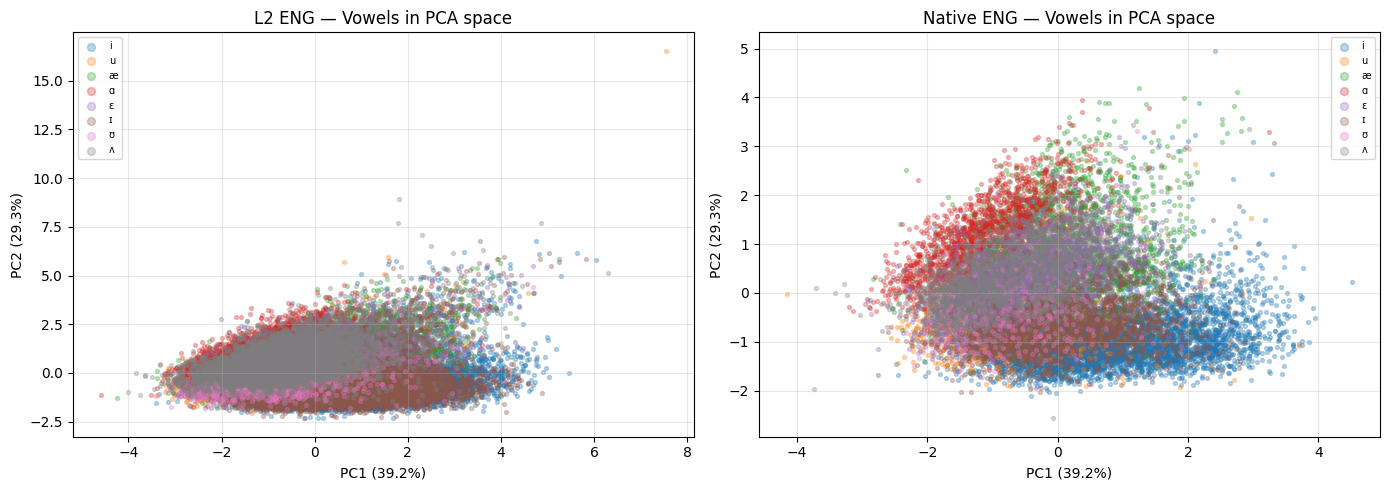


GMM (8 components) vs true vowel labels — Adjusted Rand Index: 0.179


c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


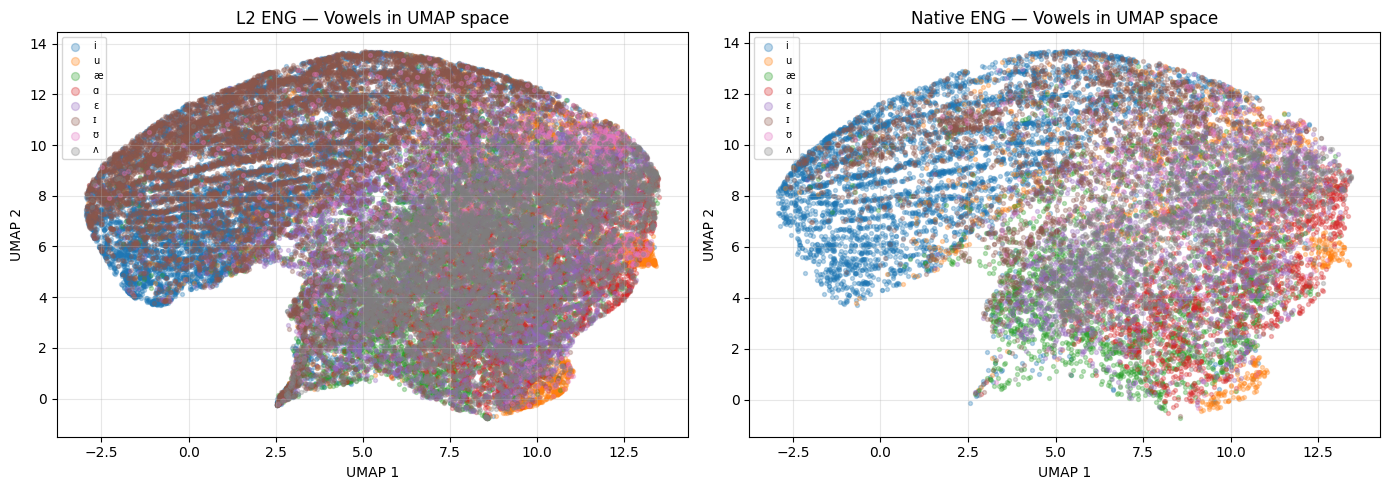

In [18]:
# ── Cell 8: Unsupervised exploration — PCA + GMM + UMAP ──

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed; UMAP plots will be skipped.")

# ── 5a: Pool native + L2 English tokens for comparison ──
df_native_tagged = df_native.copy()
df_native_tagged["speaker_type"] = "Native ENG"
df_l2_tagged = df_l2.copy()
df_l2_tagged["speaker_type"] = "L2 ENG"
df_eng_pool = pd.concat([df_native_tagged, df_l2_tagged], ignore_index=True)

# Drop rows with NaN in feature columns
feat_for_pca = ["F1", "F2", "F3", "duration_ms"]
df_pca_ready = df_eng_pool.dropna(subset=feat_for_pca).copy()
X_pca = df_pca_ready[feat_for_pca].values

# Standardize
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca)

# ── PCA ──
pca = PCA(n_components=3)
X_pca_proj = pca.fit_transform(X_scaled)
df_pca_ready["PC1"] = X_pca_proj[:, 0]
df_pca_ready["PC2"] = X_pca_proj[:, 1]
df_pca_ready["PC3"] = X_pca_proj[:, 2]

print("PCA explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("PCA loadings (PC1, PC2, PC3):")
for i, feat in enumerate(feat_for_pca):
    print(f"  {feat:>18s}: {pca.components_[0, i]:+.3f}  {pca.components_[1, i]:+.3f}  {pca.components_[2, i]:+.3f}")

# ── Plot PCA: Native vs L2 by vowel ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (stype, grp) in zip(axes, df_pca_ready.groupby("speaker_type")):
    for vowel, vgrp in grp.groupby("ipa_symbol"):
        ax.scatter(vgrp["PC1"], vgrp["PC2"], label=vowel, alpha=0.3, s=8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(f"{stype} — Vowels in PCA space")
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# ── GMM clustering on L2 data to check phoneme alignment ──
X_l2_gmm = df_pca_ready[df_pca_ready["speaker_type"] == "L2 ENG"][feat_for_pca].values
X_l2_gmm_scaled = scaler_pca.transform(X_l2_gmm)

n_vowel_classes = df_l2["ipa_symbol"].nunique()
gmm = GaussianMixture(n_components=n_vowel_classes, covariance_type="full",
                       n_init=5, random_state=42)
gmm_labels = gmm.fit_predict(X_l2_gmm_scaled)

# Adjusted Rand Index vs true vowel labels
from sklearn.metrics import adjusted_rand_score
l2_pca_sub = df_pca_ready[df_pca_ready["speaker_type"] == "L2 ENG"].copy()
ari = adjusted_rand_score(l2_pca_sub["ipa_symbol"].values, gmm_labels)
print(f"\nGMM ({n_vowel_classes} components) vs true vowel labels — Adjusted Rand Index: {ari:.3f}")

# ── UMAP (if available) ──
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    df_pca_ready["UMAP1"] = X_umap[:, 0]
    df_pca_ready["UMAP2"] = X_umap[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (stype, grp) in zip(axes, df_pca_ready.groupby("speaker_type")):
        for vowel, vgrp in grp.groupby("ipa_symbol"):
            ax.scatter(vgrp["UMAP1"], vgrp["UMAP2"], label=vowel, alpha=0.3, s=8)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(f"{stype} — Vowels in UMAP space")
        ax.legend(fontsize=7, markerscale=2)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

## Step 6: Construct Paired Dataset

One row per **(speaker x English vowel)** pair.
- **Y** = displacement vector: L2 vowel centroid - native ENG centroid
- **X** = L1 system features + speaker metadata + vowel identity + closest-L1-vowel features

In [19]:
# ── Cell 9: Construct paired dataset (with disk cache) ──

PAIRED_CACHE = CACHE_DIR / "df_paired.csv"

if PAIRED_CACHE.exists():
    df_paired = pd.read_csv(PAIRED_CACHE)
    print(f"Loaded paired dataset from cache: {len(df_paired)} samples")
else:
    rows = []
    l1_feat_cols = [c for c in df_l1_features.columns
                    if c.startswith("l1_") and not c.startswith("_")]

    for _, sv_row in l2_speaker_vowel.iterrows():
        pid = sv_row["participant_id"]
        vowel = sv_row["vowel"]
        native_lang = sv_row["native_language"]
        gender = sv_row["gender"]

        l2_centroid = {f"l2_{fc}": sv_row[f"{fc}_mean"] for fc in FEAT_COLS_CLEAN}
        l2_spread = {f"l2_{fc}_std": sv_row[f"{fc}_std"] for fc in FEAT_COLS_CLEAN}

        if vowel not in native_centroids.index:
            continue
        nat_centroid = {f"native_{fc}": native_centroids.loc[vowel, fc]
                        for fc in FEAT_COLS_CLEAN}

        displacement = {f"disp_{fc}": l2_centroid[f"l2_{fc}"] - nat_centroid[f"native_{fc}"]
                        for fc in FEAT_COLS_CLEAN}

        l1_row = df_l1_features[df_l1_features["participant_id"] == pid]
        if l1_row.empty:
            continue
        l1_feats = l1_row.iloc[0][l1_feat_cols].to_dict()

        l1_centroids_dict = l1_row.iloc[0].get("_l1_vowel_centroids", {})
        if l1_centroids_dict:
            native_f1 = nat_centroid["native_F1"]
            native_f2 = nat_centroid["native_F2"]
            best_dist = float("inf")
            best_feats = {}
            for v_label, v_feats in l1_centroids_dict.items():
                d = np.sqrt((v_feats.get("F1", 0) - native_f1)**2 +
                            (v_feats.get("F2", 0) - native_f2)**2)
                if d < best_dist:
                    best_dist = d
                    best_feats = v_feats
            l1_feats["l1_closest_dist"] = best_dist
            for fc in FEAT_COLS_CLEAN:
                l1_feats[f"l1_closest_{fc}"] = best_feats.get(fc, float("nan"))
        else:
            l1_feats["l1_closest_dist"] = float("nan")
            for fc in FEAT_COLS_CLEAN:
                l1_feats[f"l1_closest_{fc}"] = float("nan")

        row_dict = {
            "participant_id": pid,
            "native_language": native_lang,
            "gender": gender,
            "vowel": vowel,
            "ipa_symbol": ARPABET_TO_IPA.get(vowel, vowel),
            **l1_feats,
            **l2_centroid,
            **l2_spread,
            **nat_centroid,
            **displacement,
        }
        rows.append(row_dict)

    df_paired = pd.DataFrame(rows)

    df_paired["gender_M"] = (df_paired["gender"] == "M").astype(int)
    vowel_dummies = pd.get_dummies(df_paired["vowel"], prefix="vowel").astype(int)
    df_paired = pd.concat([df_paired, vowel_dummies], axis=1)

    l1_dummies = pd.get_dummies(df_paired["native_language"], prefix="L1").astype(int)
    df_paired = pd.concat([df_paired, l1_dummies], axis=1)

    df_paired.to_csv(PAIRED_CACHE, index=False)
    print(f"Saved paired dataset cache → {PAIRED_CACHE}")

# Define input/output column sets
target_cols = [f"disp_{fc}" for fc in FEAT_COLS_CLEAN]
meta_cols = ["participant_id", "native_language", "gender", "vowel", "ipa_symbol"]
l2_info_cols = [c for c in df_paired.columns if c.startswith("l2_") or c.startswith("native_")]
feature_cols = [c for c in df_paired.columns
                if c not in meta_cols + target_cols + l2_info_cols
                and c not in ["_l1_vowel_centroids"]]

df_model = df_paired.dropna(subset=feature_cols + target_cols).copy()

print(f"Paired dataset: {len(df_model)} samples "
      f"({df_model['participant_id'].nunique()} speakers x "
      f"{df_model['vowel'].nunique()} vowels)")
print(f"Input features: {len(feature_cols)}")
print(f"Target dimensions: {len(target_cols)} — {target_cols}")
print(f"\nSamples per L1:\n{df_model['native_language'].value_counts().sort_index().to_string()}")
print(f"\nSamples per vowel:\n{df_model['vowel'].value_counts().sort_index().to_string()}")

Saved paired dataset cache → ..\Data\cache\df_paired.csv
Paired dataset: 548 samples (61 speakers x 9 vowels)
Input features: 40
Target dimensions: 4 — ['disp_F1', 'disp_F2', 'disp_F3', 'disp_duration_ms']

Samples per L1:
native_language
CMN    126
FRA      9
GER     18
KOR     99
RUS     44
SPA     99
TUR    117
VIE     36

Samples per vowel:
vowel
AA     61
AE     61
AH1    61
AH2    60
EH     61
IH     61
IY     61
UH     61
UW     61


## Step 7: Model Training & Evaluation

All models predict the **displacement vector** (L2 centroid - native centroid) from L1 system features.

Evaluation:
- **Leave-One-Language-Out (LOLO):** Hold out all speakers of one L1 at a time
- **Leave-One-Speaker-Out (LOSO):** Hold out one speaker at a time

In [21]:
# ── Cell 10: Shared evaluation framework + Ridge baseline ──

X_all = df_model[feature_cols].values.astype(float)
Y_all = df_model[target_cols].values.astype(float)
groups_lang = df_model["native_language"].values
groups_speaker = df_model["participant_id"].values

# Standardize features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_all)

def evaluate_model(model, X, Y, groups, cv_name="CV"):
    """Run leave-one-group-out CV, return predictions + metrics per target."""
    from sklearn.base import clone
    logo = LeaveOneGroupOut()
    Y_pred = np.full_like(Y, np.nan)

    for train_idx, test_idx in logo.split(X, Y, groups):
        model_clone = clone(model)
        model_clone.fit(X[train_idx], Y[train_idx])
        Y_pred[test_idx] = model_clone.predict(X[test_idx])

    metrics = {}
    for i, col in enumerate(target_cols):
        mask = ~np.isnan(Y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(Y[mask, i], Y_pred[mask, i]))
        mae = mean_absolute_error(Y[mask, i], Y_pred[mask, i])
        corr = np.corrcoef(Y[mask, i], Y_pred[mask, i])[0, 1] if mask.sum() > 2 else 0
        metrics[col] = {"RMSE": rmse, "MAE": mae, "r": corr}

    overall_rmse = np.sqrt(mean_squared_error(Y[~np.isnan(Y_pred).any(axis=1)],
                                               Y_pred[~np.isnan(Y_pred).any(axis=1)]))
    metrics["overall"] = {"RMSE": overall_rmse}

    print(f"\n── {cv_name} Results ──")
    for col, m in metrics.items():
        if col == "overall":
            print(f"  {'OVERALL':>20s}: RMSE = {m['RMSE']:.1f}")
        else:
            print(f"  {col:>20s}: RMSE = {m['RMSE']:.1f}  MAE = {m['MAE']:.1f}  r = {m['r']:.3f}")

    return Y_pred, metrics

# ── Tier 1a: Multi-output Ridge Regression ──
print("=" * 60)
print("MODEL: Multi-output Ridge Regression")
print("=" * 60)

ridge = Ridge(alpha=1.0)
multi_ridge = MultiOutputRegressor(ridge)

print("\n▸ Leave-One-Language-Out:")
Y_pred_ridge_lolo, metrics_ridge_lolo = evaluate_model(
    multi_ridge, X_scaled, Y_all, groups_lang, "LOLO Ridge")

print("\n▸ Leave-One-Speaker-Out:")
Y_pred_ridge_loso, metrics_ridge_loso = evaluate_model(
    multi_ridge, X_scaled, Y_all, groups_speaker, "LOSO Ridge")

MODEL: Multi-output Ridge Regression

▸ Leave-One-Language-Out:

── LOLO Ridge Results ──
               disp_F1: RMSE = 119.6  MAE = 85.6  r = 0.447
               disp_F2: RMSE = 146.9  MAE = 111.3  r = 0.722
               disp_F3: RMSE = 249.1  MAE = 175.6  r = 0.639
      disp_duration_ms: RMSE = 28.8  MAE = 22.6  r = 0.021
               OVERALL: RMSE = 157.1

▸ Leave-One-Speaker-Out:

── LOSO Ridge Results ──
               disp_F1: RMSE = 75.3  MAE = 54.2  r = 0.700
               disp_F2: RMSE = 132.2  MAE = 97.1  r = 0.782
               disp_F3: RMSE = 147.6  MAE = 107.4  r = 0.850
      disp_duration_ms: RMSE = 17.5  MAE = 13.7  r = 0.417
               OVERALL: RMSE = 106.4


In [22]:
# ── Cell 11: Tier 2 — Gaussian Process Regression + Gradient Boosting ──

# GPR with ARD kernel (per-feature length scales → automatic feature importance)
# Multi-output: fit one GPR per target dimension (GPR is inherently single-output)
print("=" * 60)
print("MODEL: Gaussian Process Regression (RBF + ARD)")
print("=" * 60)

n_features = X_scaled.shape[1]
kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(n_features)) + WhiteKernel(noise_level=1.0)

gpr_base = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                     normalize_y=True, random_state=42)
multi_gpr = MultiOutputRegressor(gpr_base)

print("\n▸ Leave-One-Language-Out:")
Y_pred_gpr_lolo, metrics_gpr_lolo = evaluate_model(
    multi_gpr, X_scaled, Y_all, groups_lang, "LOLO GPR")

print("\n▸ Leave-One-Speaker-Out:")
Y_pred_gpr_loso, metrics_gpr_loso = evaluate_model(
    multi_gpr, X_scaled, Y_all, groups_speaker, "LOSO GPR")

# ── Gradient Boosting ──
print("\n" + "=" * 60)
print("MODEL: Gradient Boosting Regressor")
print("=" * 60)

gb_base = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42)
multi_gb = MultiOutputRegressor(gb_base)

print("\n▸ Leave-One-Language-Out:")
Y_pred_gb_lolo, metrics_gb_lolo = evaluate_model(
    multi_gb, X_scaled, Y_all, groups_lang, "LOLO GBR")

print("\n▸ Leave-One-Speaker-Out:")
Y_pred_gb_loso, metrics_gb_loso = evaluate_model(
    multi_gb, X_scaled, Y_all, groups_speaker, "LOSO GBR")

MODEL: Gaussian Process Regression (RBF + ARD)

▸ Leave-One-Language-Out:


c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 15 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 16 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings


── LOLO GPR Results ──
               disp_F1: RMSE = 101.3  MAE = 79.5  r = 0.121
               disp_F2: RMSE = 213.4  MAE = 171.6  r = -0.112
               disp_F3: RMSE = 278.5  MAE = 225.9  r = -0.056
      disp_duration_ms: RMSE = 18.4  MAE = 14.6  r = -0.283
               OVERALL: RMSE = 182.8

▸ Leave-One-Speaker-Out:


c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 12 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 39 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings


── LOSO GPR Results ──
               disp_F1: RMSE = 76.8  MAE = 55.1  r = 0.685
               disp_F2: RMSE = 145.8  MAE = 101.9  r = 0.735
               disp_F3: RMSE = 173.8  MAE = 124.2  r = 0.788
      disp_duration_ms: RMSE = 18.3  MAE = 13.8  r = 0.353
               OVERALL: RMSE = 120.1

MODEL: Gradient Boosting Regressor

▸ Leave-One-Language-Out:

── LOLO GBR Results ──
               disp_F1: RMSE = 75.6  MAE = 55.5  r = 0.683
               disp_F2: RMSE = 137.1  MAE = 104.3  r = 0.763
               disp_F3: RMSE = 154.5  MAE = 116.2  r = 0.830
      disp_duration_ms: RMSE = 17.0  MAE = 13.6  r = 0.380
               OVERALL: RMSE = 110.3

▸ Leave-One-Speaker-Out:

── LOSO GBR Results ──
               disp_F1: RMSE = 72.0  MAE = 52.7  r = 0.711
               disp_F2: RMSE = 130.1  MAE = 96.5  r = 0.787
               disp_F3: RMSE = 143.7  MAE = 103.0  r = 0.856
      disp_duration_ms: RMSE = 16.6  MAE = 12.9  r = 0.428
               OVERALL: RMSE = 103.7


In [25]:
# ── Cell 12: Tier 3 — MLP Neural Network ──

print("=" * 60)
print("MODEL: MLP Regressor (2 hidden layers)")
print("=" * 60)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.01,  # L2 regularization
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
)

print("\n▸ Leave-One-Language-Out:")
Y_pred_mlp_lolo, metrics_mlp_lolo = evaluate_model(
    mlp, X_scaled, Y_all, groups_lang, "LOLO MLP")

print("\n▸ Leave-One-Speaker-Out:")
Y_pred_mlp_loso, metrics_mlp_loso = evaluate_model(
    mlp, X_scaled, Y_all, groups_speaker, "LOSO MLP")

MODEL: MLP Regressor (2 hidden layers)

▸ Leave-One-Language-Out:


c:\Users\BatLab\anaconda3\envs\comp_ling_project\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



── LOLO MLP Results ──
               disp_F1: RMSE = 87.3  MAE = 65.0  r = 0.519
               disp_F2: RMSE = 163.6  MAE = 128.0  r = 0.634
               disp_F3: RMSE = 187.1  MAE = 144.8  r = 0.777
      disp_duration_ms: RMSE = 18.4  MAE = 14.1  r = 0.283
               OVERALL: RMSE = 132.1

▸ Leave-One-Speaker-Out:

── LOSO MLP Results ──
               disp_F1: RMSE = 71.0  MAE = 52.7  r = 0.725
               disp_F2: RMSE = 133.7  MAE = 98.6  r = 0.780
               disp_F3: RMSE = 152.2  MAE = 109.2  r = 0.838
      disp_duration_ms: RMSE = 17.3  MAE = 13.6  r = 0.323
               OVERALL: RMSE = 107.7


## Step 8: Comparative Evaluation & Visualization

Summary comparison of all models, feature importance analysis, and predicted-vs-actual vowel quadrilateral overlays.

MODEL COMPARISON SUMMARY
Model   CV  Overall_RMSE  disp_F1_RMSE  disp_F1_r  disp_F2_RMSE  disp_F2_r  disp_F3_RMSE  disp_F3_r  disp_duration_ms_RMSE  disp_duration_ms_r
Ridge LOLO        157.13        119.63       0.45        146.85       0.72        249.11       0.64                  28.75                0.02
Ridge LOSO        106.35         75.25       0.70        132.24       0.78        147.61       0.85                  17.50                0.42
  GPR LOLO        182.83        101.28       0.12        213.37      -0.11        278.54      -0.06                  18.36               -0.28
  GPR LOSO        120.10         76.78       0.69        145.85       0.73        173.78       0.79                  18.30                0.35
  GBR LOLO        110.32         75.63       0.68        137.08       0.76        154.54       0.83                  16.99                0.38
  GBR LOSO        103.72         72.05       0.71        130.08       0.79        143.68       0.86                  

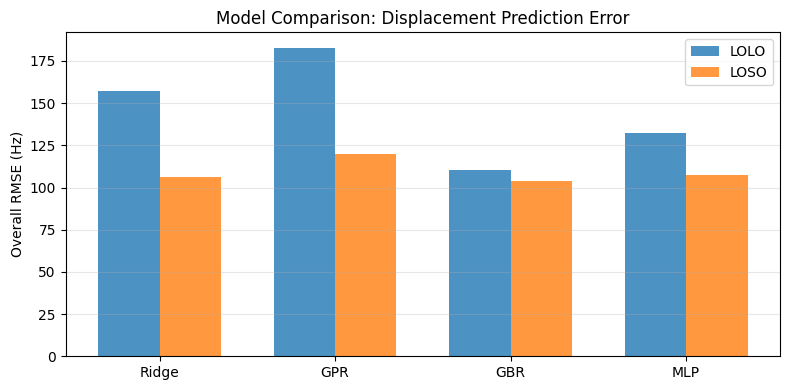

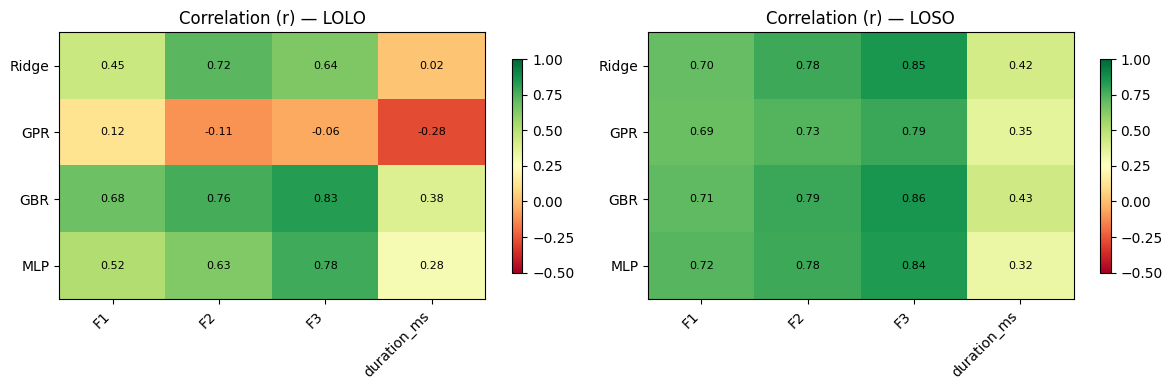

In [24]:
# ── Cell 13: Model comparison summary ──

all_metrics = {
    "Ridge": {"LOLO": metrics_ridge_lolo, "LOSO": metrics_ridge_loso},
    "GPR": {"LOLO": metrics_gpr_lolo, "LOSO": metrics_gpr_loso},
    "GBR": {"LOLO": metrics_gb_lolo, "LOSO": metrics_gb_loso},
    "MLP": {"LOLO": metrics_mlp_lolo, "LOSO": metrics_mlp_loso},
}

# ── Summary table ──
summary_rows = []
for model_name, cv_dict in all_metrics.items():
    for cv_name, metrics in cv_dict.items():
        row = {"Model": model_name, "CV": cv_name}
        row["Overall_RMSE"] = metrics["overall"]["RMSE"]
        for tc in target_cols:
            row[f"{tc}_RMSE"] = metrics[tc]["RMSE"]
            row[f"{tc}_r"] = metrics[tc]["r"]
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(df_summary.to_string(index=False, float_format="%.2f"))

# ── Bar chart: Overall RMSE by model and CV type ──
fig, ax = plt.subplots(figsize=(8, 4))
models = list(all_metrics.keys())
lolo_rmse = [all_metrics[m]["LOLO"]["overall"]["RMSE"] for m in models]
loso_rmse = [all_metrics[m]["LOSO"]["overall"]["RMSE"] for m in models]

x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, lolo_rmse, width, label="LOLO", alpha=0.8)
ax.bar(x + width/2, loso_rmse, width, label="LOSO", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Overall RMSE (Hz)")
ax.set_title("Model Comparison: Displacement Prediction Error")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

# ── Per-target correlation heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cv_name in zip(axes, ["LOLO", "LOSO"]):
    r_matrix = np.zeros((len(models), len(target_cols)))
    for i, m in enumerate(models):
        for j, tc in enumerate(target_cols):
            r_matrix[i, j] = all_metrics[m][cv_name][tc]["r"]
    im = ax.imshow(r_matrix, cmap="RdYlGn", vmin=-0.5, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(target_cols)))
    ax.set_xticklabels([tc.replace("disp_", "") for tc in target_cols], rotation=45, ha="right")
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models)
    ax.set_title(f"Correlation (r) — {cv_name}")
    for i in range(len(models)):
        for j in range(len(target_cols)):
            ax.text(j, i, f"{r_matrix[i,j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

In [ ]:
# ── Cell 14: Feature importance (Gradient Boosting) ──

# Refit GBR on all data to inspect feature importances
multi_gb_full = MultiOutputRegressor(
    GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                               subsample=0.8, random_state=42))
multi_gb_full.fit(X_scaled, Y_all)

# Average importance across all output dimensions
importances = np.mean([est.feature_importances_ for est in multi_gb_full.estimators_], axis=0)
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("Top 20 features by GBR importance:")
print(feat_imp.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(20).plot.barh(ax=ax)
ax.set_xlabel("Mean Feature Importance (GBR)")
ax.set_title("Top 20 Input Features for Predicting L2 Vowel Displacement")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

In [ ]:
# ── Cell 15: Predicted vs actual vowel quadrilaterals per L1 ──
# Uses the best-performing model's LOLO predictions

# Pick the model with lowest LOLO overall RMSE
best_model_name = min(all_metrics.keys(),
                      key=lambda m: all_metrics[m]["LOLO"]["overall"]["RMSE"])
print(f"Best LOLO model: {best_model_name}")

pred_map = {
    "Ridge": Y_pred_ridge_lolo,
    "GPR": Y_pred_gpr_lolo,
    "GBR": Y_pred_gb_lolo,
    "MLP": Y_pred_mlp_lolo,
}
Y_pred_best = pred_map[best_model_name]

# Reconstruct predicted L2 centroids = native + predicted displacement
df_eval = df_model.copy()
for i, tc in enumerate(target_cols):
    fc = tc.replace("disp_", "")
    df_eval[f"pred_l2_{fc}"] = df_eval[f"native_{fc}"] + Y_pred_best[:, i]
    df_eval[f"actual_l2_{fc}"] = df_eval[f"native_{fc}"] + df_eval[tc]

# Plot per-language predicted vs actual vowel quadrilaterals in F1-F2
languages = sorted(df_eval["native_language"].unique())
n_langs = len(languages)
ncols = min(4, n_langs)
nrows = (n_langs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)

for idx, lang in enumerate(languages):
    ax = axes[idx // ncols, idx % ncols]
    sub = df_eval[df_eval["native_language"] == lang]

    # Group by vowel: mean predicted and actual
    for vowel in sorted(sub["vowel"].unique()):
        vsub = sub[sub["vowel"] == vowel]
        ipa = ARPABET_TO_IPA.get(vowel, vowel)

        act_f2 = vsub["actual_l2_F2"].mean()
        act_f1 = vsub["actual_l2_F1"].mean()
        pred_f2 = vsub["pred_l2_F2"].mean()
        pred_f1 = vsub["pred_l2_F1"].mean()

        ax.scatter(act_f2, act_f1, marker="o", s=50, zorder=5,
                   label=f"/{ipa}/ actual" if idx == 0 else "")
        ax.scatter(pred_f2, pred_f1, marker="x", s=50, zorder=5,
                   label=f"/{ipa}/ pred" if idx == 0 else "")
        ax.annotate(ipa, (act_f2, act_f1), fontsize=7, fontweight="bold",
                    textcoords="offset points", xytext=(4, 4),
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])
        # Arrow from predicted to actual
        ax.annotate("", xy=(act_f2, act_f1), xytext=(pred_f2, pred_f1),
                    arrowprops=dict(arrowstyle="->", color="gray", alpha=0.5, lw=0.8))

    ax.set_title(f"L1 = {lang} (n={len(sub)})", fontsize=9)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xlabel("F2 (Hz)")
    ax.set_ylabel("F1 (Hz)")
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_langs, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle(f"Predicted (x) vs Actual (o) L2 Vowel Centroids — {best_model_name} LOLO",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

In [ ]:
# ── Cell 16: Displacement error analysis by L1 and by vowel ──

df_eval["disp_error_F1"] = Y_pred_best[:, target_cols.index("disp_F1")] - df_eval["disp_F1"]
df_eval["disp_error_F2"] = Y_pred_best[:, target_cols.index("disp_F2")] - df_eval["disp_F2"]
df_eval["disp_error_eucl"] = np.sqrt(df_eval["disp_error_F1"]**2 + df_eval["disp_error_F2"]**2)

# Error by L1
print(f"Mean Euclidean displacement error by L1 ({best_model_name} LOLO):")
err_by_l1 = df_eval.groupby("native_language")["disp_error_eucl"].agg(["mean", "std", "count"])
print(err_by_l1.round(1).to_string())

# Error by vowel
print(f"\nMean Euclidean displacement error by vowel:")
err_by_vowel = df_eval.groupby("ipa_symbol")["disp_error_eucl"].agg(["mean", "std", "count"])
print(err_by_vowel.round(1).to_string())

# Box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_eval.boxplot(column="disp_error_eucl", by="native_language", ax=axes[0])
axes[0].set_title("Prediction Error by L1")
axes[0].set_xlabel("L1")
axes[0].set_ylabel("Euclidean Error (Hz)")
axes[0].tick_params(axis="x", rotation=45)

df_eval.boxplot(column="disp_error_eucl", by="ipa_symbol", ax=axes[1])
axes[1].set_title("Prediction Error by Vowel")
axes[1].set_xlabel("Vowel")
axes[1].set_ylabel("Euclidean Error (Hz)")

fig.suptitle(f"Displacement Prediction Error — {best_model_name} LOLO", fontsize=11)
fig.tight_layout()
plt.show()

print("\n── Pipeline complete ──")